Imports

In [1]:
!pip install shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import shap

import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [3]:
df = pd.read_csv("creditcard.csv")

print(df.shape)

df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Missing Values

In [5]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Fraud Distribution

Class
0    284315
1       492
Name: count, dtype: int64


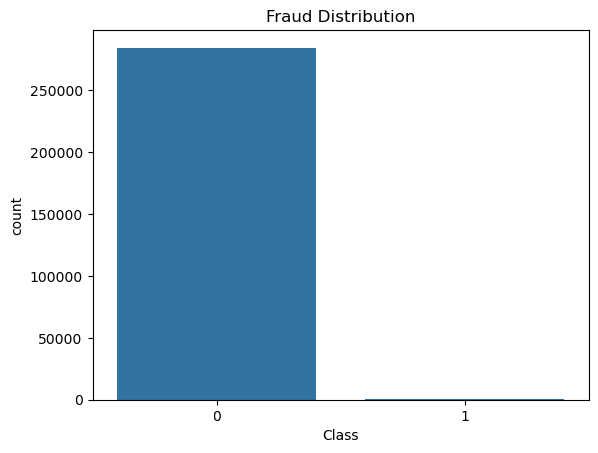

In [6]:
fraud_counts = df["Class"].value_counts()

print(fraud_counts)

sns.countplot(
    x="Class",
    data=df
)

plt.title("Fraud Distribution")
plt.show()

Fraud Percentage

In [7]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True)
    * 100
)

print(fraud_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Feature Scaling

In [8]:
scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(
    df["Amount"].values.reshape(-1,1)
)

df["scaled_time"] = scaler.fit_transform(
    df["Time"].values.reshape(-1,1)
)

df.drop(
    ["Amount","Time"],
    axis=1,
    inplace=True
)

Features and Target

In [9]:
X = df.drop("Class", axis=1)

y = df["Class"]

Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Apply SMOTE

In [11]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


Decision Tree Model

In [12]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(
    X_train_smote,
    y_train_smote
)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Predictions

In [13]:
dt_preds = dt_model.predict(X_test)

dt_probs = dt_model.predict_proba(X_test)[:,1]

Evaluation Function

In [14]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    print(f"\n{model_name}")

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1:",
        f1_score(
            y_true,
            y_pred
        )
    )

    print(
        "ROC AUC:",
        roc_auc_score(
            y_true,
            y_prob
        )
    )

Evaluate DT

In [15]:
evaluate_model(
    y_test,
    dt_preds,
    dt_probs,
    "Decision Tree"
)


Decision Tree
Accuracy: 0.9835504371335276
Precision: 0.07923771313941826
Recall: 0.8061224489795918
F1: 0.14429223744292238
ROC AUC: 0.8949992929783055


Confusion Matrix

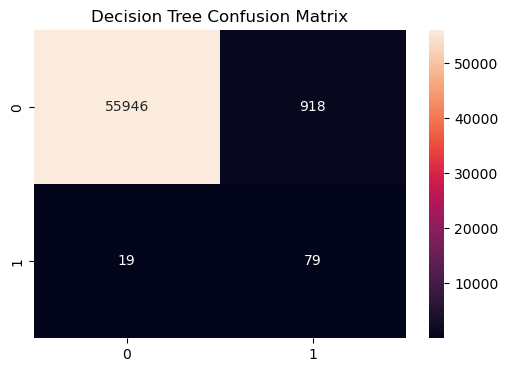

In [16]:
cm = confusion_matrix(
    y_test,
    dt_preds
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.show()

Classification Report

In [17]:
print(
    classification_report(
        y_test,
        dt_preds
    )
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.81      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.89      0.57     56962
weighted avg       1.00      0.98      0.99     56962



Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

RF Predictions

In [ ]:
rf_preds = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba(X_test)[:,1]

RF Evaluation

In [ ]:
evaluate_model(
    y_test,
    rf_preds,
    rf_probs,
    "Random Forest"
)

Feature Importance

In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

Importance Plot

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features"
)

plt.show()

SHAP Analysis

In [ ]:
explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_test
)

SHAP Summary Plot

In [ ]:
shap.summary_plot(
    shap_values[1],
    X_test
)

Cost Sensitive Learning

In [ ]:
weighted_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight={
        0:1,
        1:20
    },
    random_state=42
)

weighted_rf.fit(
    X_train,
    y_train
)

Evaluate Cost Sensitive Model

In [ ]:
weighted_preds = weighted_rf.predict(
    X_test
)

weighted_probs = weighted_rf.predict_proba(
    X_test
)[:,1]

evaluate_model(
    y_test,
    weighted_preds,
    weighted_probs,
    "Cost Sensitive RF"
)

Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.0017,
    random_state=42
)

iso.fit(X_train)

anomaly_preds = iso.predict(X_test)

anomaly_preds = np.where(
    anomaly_preds == -1,
    1,
    0
)

Evaluate Anomaly Detection

In [ ]:
print(
    classification_report(
        y_test,
        anomaly_preds
    )
)

Model Comparison Table

In [ ]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Weighted RF"
    ],

    "Accuracy":[
        accuracy_score(y_test, dt_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, weighted_preds)
    ],

    "F1":[
        f1_score(y_test, dt_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, weighted_preds)
    ]
})

results

# Fraud Detection Pipeline Summary

Steps Completed:

- Data Loading
- Fraud Distribution Analysis
- Feature Scaling
- SMOTE Oversampling
- Decision Tree Classification
- Random Forest Classification
- Cost Sensitive Learning
- Isolation Forest Anomaly Detection
- SHAP Explainability
- Model Comparison

Best Model:
(Random Forest expected)